# Lid-Driven Cavity — Ghia, Ghia & Shin (1982) Benchmark

The classic incompressible-Navier-Stokes validation case: a unit square,
no-slip on three walls, the top lid moving at `U=1`. Run to steady state at
Re = 100, 400, 1000 and compare the centerline velocity profiles against
the standard tabulated reference data from Ghia, Ghia & Shin (1982), *J.
Comput. Phys.* 48(3):387-411 (129x129 grid, vorticity-streamfunction +
multigrid -- only the converged physical steady state is being compared,
not the numerical method).

Resolution: 64x64 (chosen for interactive runtime -- see the timing/
convergence-rate estimate that motivated it; a finer grid mainly sharpens
the Re=1000 secondary-vortex visuals, it doesn't change the centerline
comparison much).

In [1]:
%matplotlib inline
import time
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import imageio_ffmpeg
from IPython.display import Image, display

import grid as g
import boundary as bnd
import pressure as pr
import solver as sv
import operators as op

matplotlib.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()
MEDIA_DIR = Path('media')
MEDIA_DIR.mkdir(exist_ok=True)

def save(fig, name):
    path = MEDIA_DIR / name
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    display(Image(filename=path))

## Reference data

Ghia, Ghia & Shin (1982) Table I (`u` along the vertical centerline `x=0.5`)
and Table II (`v` along the horizontal centerline `y=0.5`), transcribed
from the well-known published tables.

In [2]:
Y_STATIONS = [1.0000, 0.9766, 0.9688, 0.9609, 0.9531, 0.8516, 0.7344, 0.6172,
              0.5000, 0.4531, 0.2813, 0.1719, 0.1016, 0.0703, 0.0625, 0.0547, 0.0000]

U_CENTERLINE = {
    100: [1.0000, 0.84123, 0.78871, 0.73722, 0.68717, 0.23151, 0.00332, -0.13641,
          -0.20581, -0.21090, -0.15662, -0.10150, -0.06434, -0.04775, -0.04192, -0.03717, 0.0000],
    400: [1.0000, 0.75837, 0.68439, 0.61756, 0.55892, 0.29093, 0.16256, 0.02135,
          -0.11477, -0.17119, -0.32726, -0.24299, -0.14612, -0.10338, -0.09266, -0.08186, 0.0000],
    1000: [1.0000, 0.65928, 0.57492, 0.51117, 0.46604, 0.33304, 0.18719, 0.05702,
           -0.06080, -0.10648, -0.27805, -0.38289, -0.29730, -0.22220, -0.20196, -0.18109, 0.0000],
}

X_STATIONS = [1.0000, 0.9688, 0.9609, 0.9531, 0.9453, 0.9063, 0.8594, 0.8047,
              0.5000, 0.2344, 0.2266, 0.1563, 0.0938, 0.0781, 0.0703, 0.0625, 0.0000]

V_CENTERLINE = {
    100: [0.0000, -0.05906, -0.07391, -0.08864, -0.10313, -0.16914, -0.22445, -0.24533,
          0.05454, 0.17527, 0.17507, 0.16077, 0.12317, 0.10890, 0.10091, 0.09233, 0.0000],
    400: [0.0000, -0.12146, -0.15663, -0.19254, -0.22847, -0.23827, -0.44993, -0.38598,
          0.05186, 0.30174, 0.30203, 0.28124, 0.22965, 0.20920, 0.19713, 0.18360, 0.0000],
    1000: [0.0000, -0.21388, -0.27669, -0.33714, -0.39188, -0.51550, -0.42665, -0.31966,
           0.02526, 0.32235, 0.33075, 0.37095, 0.32627, 0.30353, 0.29012, 0.27485, 0.0000],
}

In [3]:
def run_lid_driven_cavity(nx, ny, Re, U_lid=1.0, tol=1e-6, max_steps=15000, dt_max=0.01, record_every=None):
    """Run from rest to steady state, monitoring max|div| and per-step
    kinetic-energy change as the convergence criterion. If record_every is
    given, also saves a (t, vorticity) snapshot every that many steps, for
    animating the flow's development afterward."""
    nu = U_lid / Re
    grid_c = g.make_grid(nx, ny, 1.0, 1.0)
    bc = {'left': {'type': 'no_slip'}, 'right': {'type': 'no_slip'},
          'bottom': {'type': 'no_slip'}, 'top': {'type': 'no_slip', 'value': U_lid}}
    system = sv.build_system(grid_c, bc)
    u = np.zeros((nx + 1, ny))
    v = np.zeros((nx, ny + 1))
    ke_prev, ke_history, max_div, t = 0.0, [], 0.0, 0.0
    frames = []
    for step in range(max_steps):
        dt = sv.cfl_timestep(u, v, grid_c.dx, grid_c.dy, cfl_number=0.5, dt_max=dt_max)
        u, v, p, max_div = sv.step(u, v, grid_c, bc, system, dt, nu)
        t += dt
        ke = 0.5 * (np.sum(u ** 2) + np.sum(v ** 2))
        ke_history.append(ke)
        if record_every is not None and step % record_every == 0:
            zeta = op.vorticity(u, v, grid_c.dx, grid_c.dy, cell_mask=grid_c.cell_mask)
            u_c, v_c = g.velocity_at_centers(u, v)
            frames.append((t, zeta.copy(), u_c.copy(), v_c.copy()))
        rel_change = abs(ke - ke_prev) / max(ke, 1e-12)
        ke_prev = ke
        if step > 200 and rel_change < tol:
            break
    result = {'grid': grid_c, 'u': u, 'v': v, 'p': p, 'max_div': max_div,
              'steps': step + 1, 'ke_history': ke_history, 'nu': nu, 'Re': Re}
    if record_every is not None:
        result['frames'] = frames
    return result


failures = []

def check(name, cond, detail=""):
    status = "PASS" if cond else "FAIL"
    print(f"[{status}] {name}  {detail}")
    if not cond:
        failures.append(name)

In [4]:
nx = ny = 64
results = {}
for Re in (100, 400, 1000):
    t0 = time.time()
    res = run_lid_driven_cavity(nx, ny, Re)
    t1 = time.time()
    results[Re] = res
    check(f"Re={Re}: converged within max_steps", res['steps'] < 15000,
          f"{res['steps']} steps, {t1-t0:.1f}s, max|div|={res['max_div']:.2e}")

[PASS] Re=100: converged within max_steps  1741 steps, 2.9s, max|div|=6.01e-14


[PASS] Re=400: converged within max_steps  3597 steps, 4.8s, max|div|=1.08e-13


[PASS] Re=1000: converged within max_steps  3796 steps, 4.5s, max|div|=8.99e-14


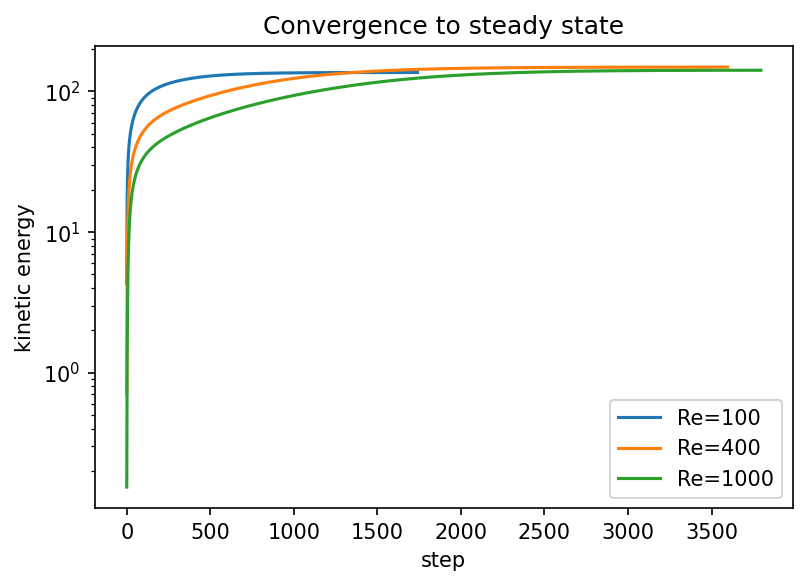

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
for Re, res in results.items():
    ax.semilogy(res['ke_history'], label=f'Re={Re}')
ax.set_xlabel('step'); ax.set_ylabel('kinetic energy')
ax.legend()
ax.set_title('Convergence to steady state')
save(fig, 'cavity_convergence.png')

## Quantitative comparison: centerline velocity profiles vs. Ghia et al. (1982)

[PASS] Re=100: u-centerline matches Ghia et al.  RMS error=0.0128
[PASS] Re=100: v-centerline matches Ghia et al.  RMS error=0.0171
[PASS] Re=400: u-centerline matches Ghia et al.  RMS error=0.0277
[PASS] Re=400: v-centerline matches Ghia et al.  RMS error=0.0327
[PASS] Re=1000: u-centerline matches Ghia et al.  RMS error=0.0418
[PASS] Re=1000: v-centerline matches Ghia et al.  RMS error=0.0381


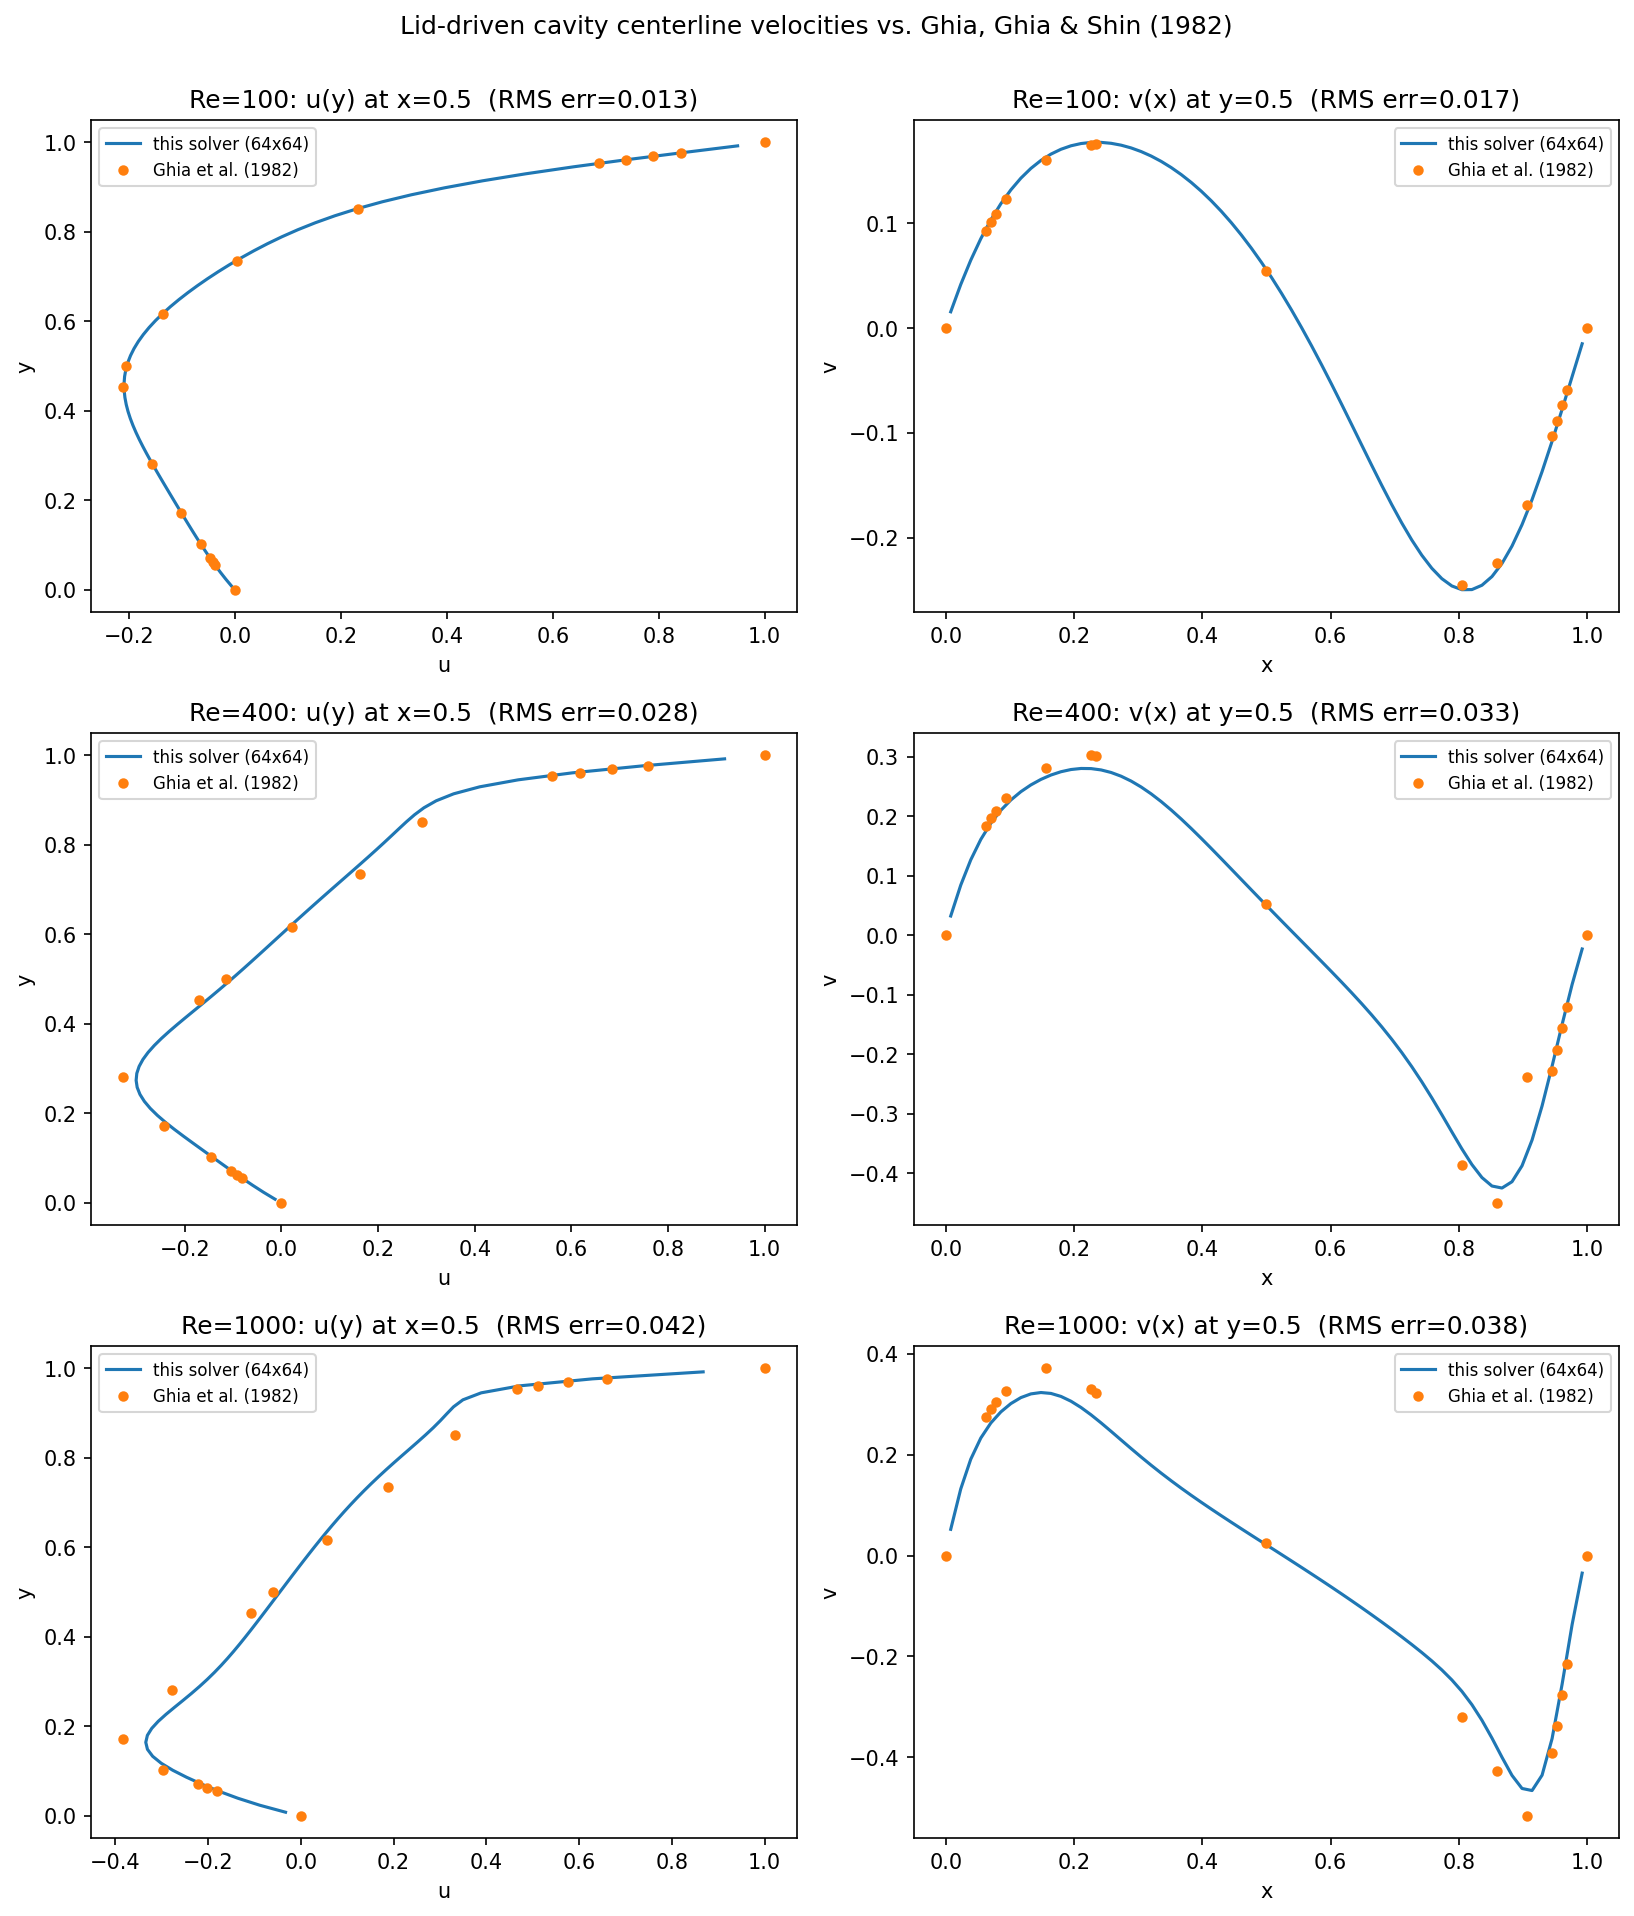

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(11, 13))
for row, Re in enumerate((100, 400, 1000)):
    res = results[Re]
    grid_c, u, v = res['grid'], res['u'], res['v']
    ix = grid_c.nx // 2  # x=0.5 exactly, since nx is even
    jy = grid_c.ny // 2  # y=0.5 exactly, since ny is even
    yu = (np.arange(grid_c.ny) + 0.5) * grid_c.dy
    xv = (np.arange(grid_c.nx) + 0.5) * grid_c.dx

    u_profile = u[ix, :]
    v_profile = v[:, jy]

    u_ghia_interp = np.interp(yu, Y_STATIONS[::-1], U_CENTERLINE[Re][::-1])
    v_ghia_interp = np.interp(xv, X_STATIONS[::-1], V_CENTERLINE[Re][::-1])
    u_err = np.sqrt(np.mean((u_profile - u_ghia_interp) ** 2))
    v_err = np.sqrt(np.mean((v_profile - v_ghia_interp) ** 2))
    check(f"Re={Re}: u-centerline matches Ghia et al.", u_err < 0.08, f"RMS error={u_err:.4f}")
    check(f"Re={Re}: v-centerline matches Ghia et al.", v_err < 0.08, f"RMS error={v_err:.4f}")

    axes[row, 0].plot(u_profile, yu, '-', label='this solver (64x64)')
    axes[row, 0].plot(U_CENTERLINE[Re], Y_STATIONS, 'o', markersize=4, label='Ghia et al. (1982)')
    axes[row, 0].set_xlabel('u'); axes[row, 0].set_ylabel('y')
    axes[row, 0].set_title(f'Re={Re}: u(y) at x=0.5  (RMS err={u_err:.3f})')
    axes[row, 0].legend(fontsize=8)

    axes[row, 1].plot(xv, v_profile, '-', label='this solver (64x64)')
    axes[row, 1].plot(X_STATIONS, V_CENTERLINE[Re], 'o', markersize=4, label='Ghia et al. (1982)')
    axes[row, 1].set_xlabel('x'); axes[row, 1].set_ylabel('v')
    axes[row, 1].set_title(f'Re={Re}: v(x) at y=0.5  (RMS err={v_err:.3f})')
    axes[row, 1].legend(fontsize=8)

fig.suptitle('Lid-driven cavity centerline velocities vs. Ghia, Ghia & Shin (1982)')
fig.tight_layout(rect=[0, 0, 1, 0.98])
save(fig, 'cavity_ghia_comparison.png')

## Qualitative check: streamlines and vorticity

At Re=100, expect a single dominant primary vortex with at most a
barely-visible bottom-right secondary corner vortex; by Re=1000, both
bottom-left and bottom-right secondary corner vortices should be visible.

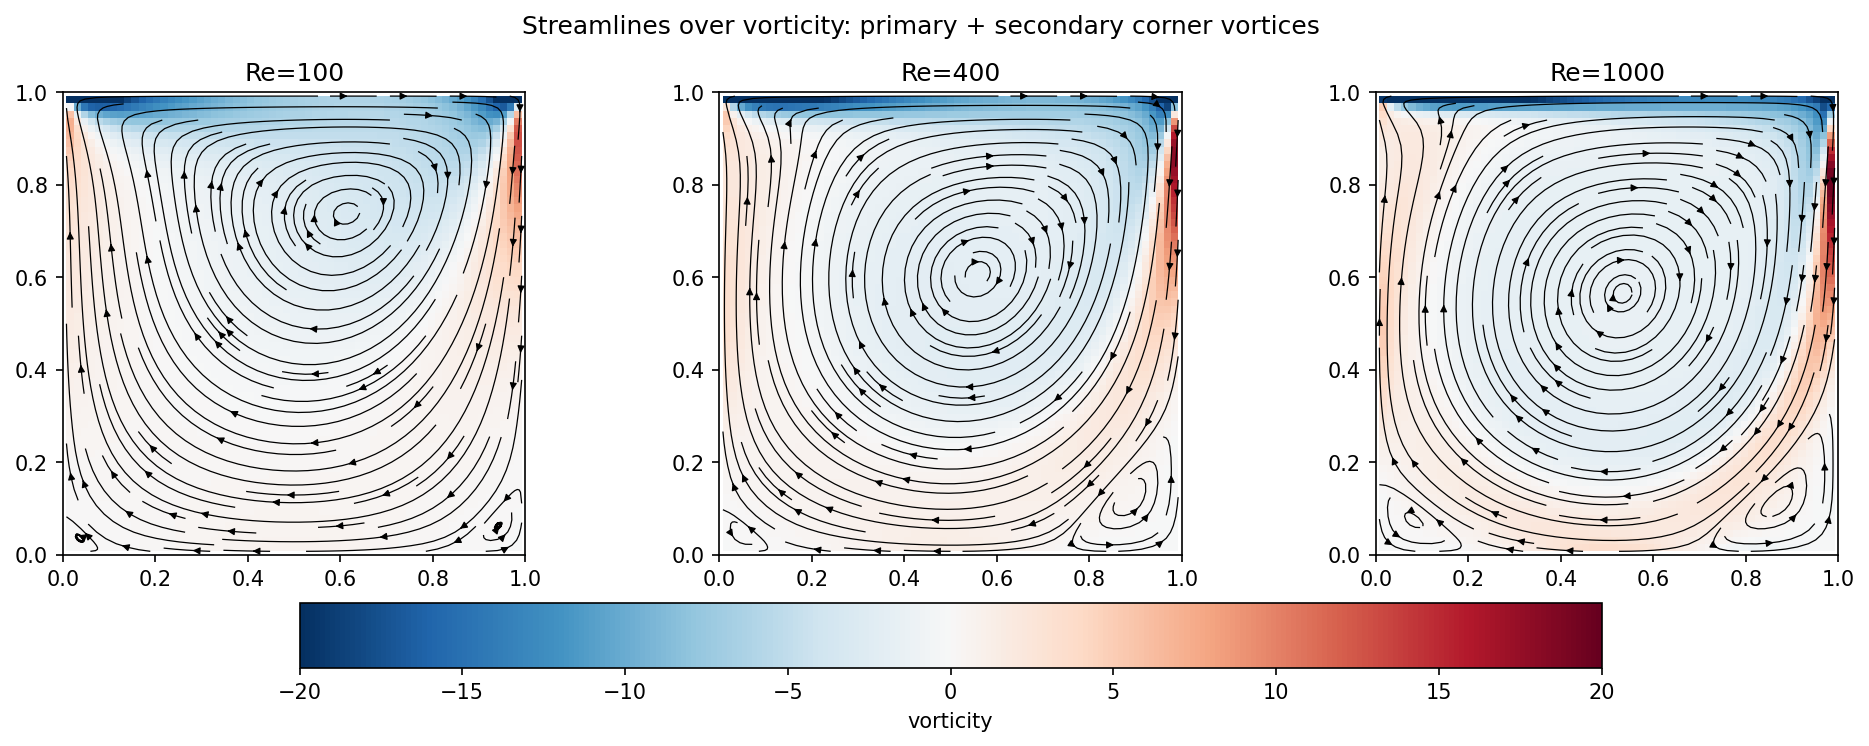

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))
for ax, Re in zip(axes, (100, 400, 1000)):
    res = results[Re]
    grid_c, u, v = res['grid'], res['u'], res['v']
    zeta = op.vorticity(u, v, grid_c.dx, grid_c.dy)
    u_c, v_c = g.velocity_at_centers(u, v)
    xc = (np.arange(grid_c.nx) + 0.5) * grid_c.dx
    yc = (np.arange(grid_c.ny) + 0.5) * grid_c.dy
    xcorner = np.arange(1, grid_c.nx) * grid_c.dx
    ycorner = np.arange(1, grid_c.ny) * grid_c.dy

    im = ax.pcolormesh(xcorner, ycorner, zeta.T, cmap='RdBu_r', vmin=-20, vmax=20, shading='auto')
    ax.streamplot(xc, yc, u_c.T, v_c.T, density=1.3, color='k', linewidth=0.6, arrowsize=0.7)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.set_title(f'Re={Re}')
plt.colorbar(im, ax=axes, shrink=0.7, label='vorticity', location='bottom', pad=0.08)
fig.suptitle('Streamlines over vorticity: primary + secondary corner vortices')
save(fig, 'cavity_streamlines_vorticity.png')

## Animation: flow development from rest

The static plots above only show the converged steady state. Re-running
each case with periodic vorticity snapshots shows the more interesting
part: the lid impulsively starts moving, a single corner roll forms and
grows into the primary vortex, and -- at the higher Reynolds numbers --
the secondary corner vortices spin up well after the primary one, visibly
lagging behind it.

In [8]:
target_frames = 150
anim_results = {}
for Re in (100, 400, 1000):
    stride = max(1, results[Re]['steps'] // target_frames)
    t0 = time.time()
    anim_results[Re] = run_lid_driven_cavity(nx, ny, Re, record_every=stride)
    t1 = time.time()
    print(f"Re={Re}: recorded {len(anim_results[Re]['frames'])} frames ({t1-t0:.1f}s)")

Re=100: recorded 159 frames (3.7s)


Re=400: recorded 157 frames (5.0s)


Re=1000: recorded 152 frames (4.6s)


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.2))
xc = (np.arange(nx) + 0.5) / nx
yc = (np.arange(ny) + 0.5) / ny
n_frames = max(len(anim_results[Re]['frames']) for Re in (100, 400, 1000))

# Full clear-and-redraw per frame: StreamplotSet's removal API is not
# consistent enough across matplotlib versions to trust incremental
# updates, and this animation is rendered once (not per-solver-step), so
# the extra draw cost doesn't matter the way it would inside the solver.
def update(i):
    for ax, Re in zip(axes, (100, 400, 1000)):
        ax.cla()
        frames = anim_results[Re]['frames']
        idx = min(i, len(frames) - 1)
        t_i, zeta, u_c, v_c = frames[idx]
        im = ax.imshow(zeta.T, origin='lower', cmap='RdBu_r', vmin=-20, vmax=20, extent=[0, 1, 0, 1])
        ax.streamplot(xc, yc, u_c.T, v_c.T, density=1.0, color='k', linewidth=0.6, arrowsize=0.7)
        ax.set_title(f'Re={Re}, t={t_i:.2f}')
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.set_aspect('equal')
    return []

update(0)
plt.colorbar(axes[-1].images[0], ax=axes, shrink=0.7, label='vorticity', location='bottom', pad=0.08)
fig.suptitle('Lid-driven cavity: vorticity + streamlines, development from rest')

ani = animation.FuncAnimation(fig, update, frames=n_frames, interval=60, blit=False)
ani.save(MEDIA_DIR / 'cavity_vorticity_evolution.mp4', writer='ffmpeg', fps=20, dpi=110)
plt.close(fig)
print(f"Saved animation to {MEDIA_DIR / 'cavity_vorticity_evolution.mp4'}")

Saved animation to media\cavity_vorticity_evolution.mp4


In [10]:
assert not failures, f"Failing checks: {failures}"
print("All Phase 6 checks passed.")

All Phase 6 checks passed.
